In [1]:
a1 = 19 # C
a2 = 1 # A
a3 = 13 # Л

b1 = 33 # Я
b2 = 19 # С
b3 = 14 # М

c1 = 10 # И
c2 = 5 # Д
c3 = 18 # Р

In [2]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np
import math
import time
import sys
from gekko import GEKKO

# Задача 1

Аналитическре решение получено с помощью этого сайта: https://dio.fan/problems/extremum_varcalc

Условие Лежандра для минимума выполняется


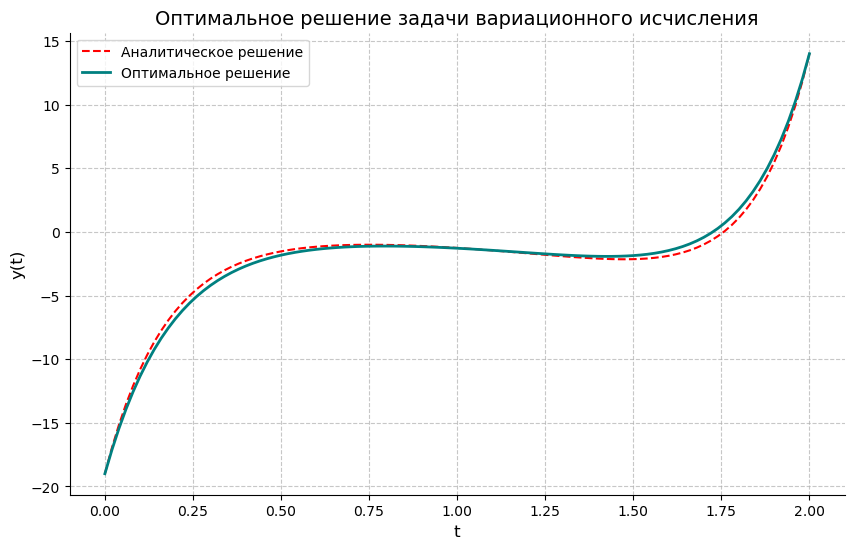

Значение функционала: 132615.04548707866
Точка экстремума: [-19.         -17.12626736 -15.44072021 -13.92472762 -12.56124788
 -11.33516163 -10.232763    -9.24168459  -8.35093255  -7.55045125
  -6.83135565  -6.18548126  -5.60568931  -5.08531306  -4.61860904
  -4.20018298  -3.82531306  -3.48969468  -3.18943623  -2.92116394
  -2.68161458  -2.46817951  -2.27813271  -2.10930577  -1.95964177
  -1.82726206  -1.71057325  -1.60812294  -1.5185312   -1.44063143
  -1.37332471  -1.31570826  -1.26679026  -1.22605442  -1.19250061
  -1.16572689  -1.1450212   -1.12987215  -1.11991771  -1.1146662
  -1.11376558  -1.11699304  -1.12371553  -1.13409447  -1.14743401
  -1.16391022  -1.18310636  -1.20484159  -1.22896436  -1.25517733
  -1.28330864  -1.3133303   -1.34491347  -1.3781109   -1.4125911
  -1.44812921  -1.48462402  -1.52167224  -1.55921928  -1.59698278
  -1.63467702  -1.67201315  -1.70861974  -1.74408673  -1.77795663
  -1.80985402  -1.83912492  -1.86525727  -1.88761678  -1.90525477
  -1.9175961   -1.9

In [3]:
# Дискретизация
num_of_fractions = 101
t_full = np.linspace(0, 2, num_of_fractions)
dt = t_full[1] - t_full[0]

# Функция для вычисления функционала
def f(y):
    dy = (y[1:] - y[:-1]) / dt
    y = y[1:]
    t = t_full[1:]
    return np.sum(dy ** 2 + a1 * y * dy + b1 * (y ** 2) + c1 * y * np.exp(2 * t))

# Граничные условия и начальное приближение
EPS = np.finfo(float).eps
y0 = [0.2 for _ in t_full] 
bounds = [(None, None) for _ in t_full]
bounds[0] = (-b2 - EPS, -b2 + EPS)
bounds[-1] = (b3 - EPS, b3 + EPS)

# Оптимизация
res = minimize(f, y0, method='L-BFGS-B', bounds=bounds)

# Проверка условия Лежандра
second_derivative = 2 # Путем пристального взгляда получено

if np.all(second_derivative >= 0):
    print("Условие Лежандра для минимума выполняется")
else:
    print("Условие Лежандра для минимума не выполняется")
    
# Проверим совпадает ли полученное решение с аналитическим
def f_analytical(x):
    num1 = (546 + 5 * np.exp(4) * np.exp(2 * np.sqrt(33)) + 406 * np.exp(2 * np.sqrt(33))) * np.exp(np.sqrt(33) * x)
    den1 = -29 + 29 * np.exp(4 * np.sqrt(33))
    
    num2 = (-546 * np.exp(4 * np.sqrt(33)) - 406 * np.exp(2 * np.sqrt(33)) - 5 * np.exp(4) * np.exp(2 * np.sqrt(33))) * np.exp(-np.sqrt(33) * x)
    den2 = -29 + 29 * np.exp(4 * np.sqrt(33))
    
    term3 = (5 * np.exp(2*x)) / 29
    

    return (num1/den1) + (num2/den2) - term3

y_values = [f_analytical(x) for x in t_full]

# Визуализация

plt.figure(figsize=(10, 6))
# Аналитическое решение
plt.plot(t_full, y_values, linestyle='--', color='red', label='Аналитическое решение')
# Полученное решение
plt.plot(t_full, res.x, linewidth=2, color='teal', label='Оптимальное решение')
plt.title('Оптимальное решение задачи вариационного исчисления', fontsize=14)
plt.xlabel('t', fontsize=12)
plt.ylabel('y(t)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)
plt.savefig('Задача_1')
plt.show()

print(f"Значение функционала: {res.fun}")
print(f"Точка экстремума: {res.x}")

Итог: был найден сильный минимум

# Задача 2

In [4]:
# Инициализируем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=a1)
z = m.Var(value=0)
u = m.Var(value=0, lb=-c1, ub=c2)
t = m.Var(value=0)

# Отмечаем последнюю точку временной шкалы
p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == a3 * y + u)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == b1 * y - b2 * u) 

m.Obj(z * final * (-1))    # Целевая функция (ищем максимум)
m.options.IMODE = 6 # Задача оптимального управления/динамического программирования
m.solve(disp=False)

Exception: @error: Solution Not Found


In [5]:
# Инициализируем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=a1)
z = m.Var(value=0)
u = m.Var(value=0, lb=-c1, ub=c2)
t = m.Var(value=0)

# Отмечаем последнюю точку временной шкалы
p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == a3 * y + u)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == b1 * y - b2 * u)

m.Obj(z * final)    # Целевая функция (ищем минимум)
m.options.IMODE = 6 # Задача оптимального управления/динамического программирования
m.solve(disp=False)

Exception: @error: Solution Not Found


Итог: при заданных параметрах решение найти не получится

После экспериментов, удалось установить, что при a3=0.25 - решения есть! И минимум, и максимум

In [6]:
# Инициализируем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=a1)
z = m.Var(value=0)
u = m.Var(value=0, lb=-c1, ub=c2)
t = m.Var(value=0)

# Отмечаем последнюю точку временной шкалы
p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == 0.25 * y + u)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == b1 * y - b2 * u) 

m.Obj(z * final * (-1))    # Целевая функция (ищем максимум)
m.options.IMODE = 6 # Задача оптимального управления/динамического программирования
m.solve(disp=False)

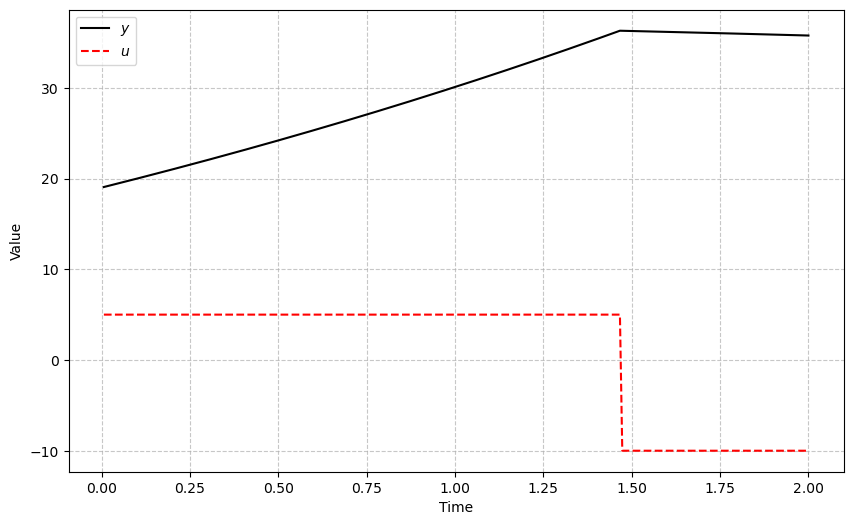

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(m.time[1:], y.value[1:], 'k-', label=r'$y$')
plt.plot(m.time[1:],u.value[1:],'r--',label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Задача_2_максимум.png')

In [8]:
# Инициализируем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=a1)
z = m.Var(value=0)
u = m.Var(value=0, lb=-c1, ub=c2)
t = m.Var(value=0)

# Отмечаем последнюю точку временной шкалы
p = np.zeros(nt)
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == 0.25 * y + u)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == b1 * y - b2 * u) 

m.Obj(z * final)    # Целевая функция (ищем минимум)
m.options.IMODE = 6 # Задача оптимального управления/динамического программирования
m.solve(disp=False)

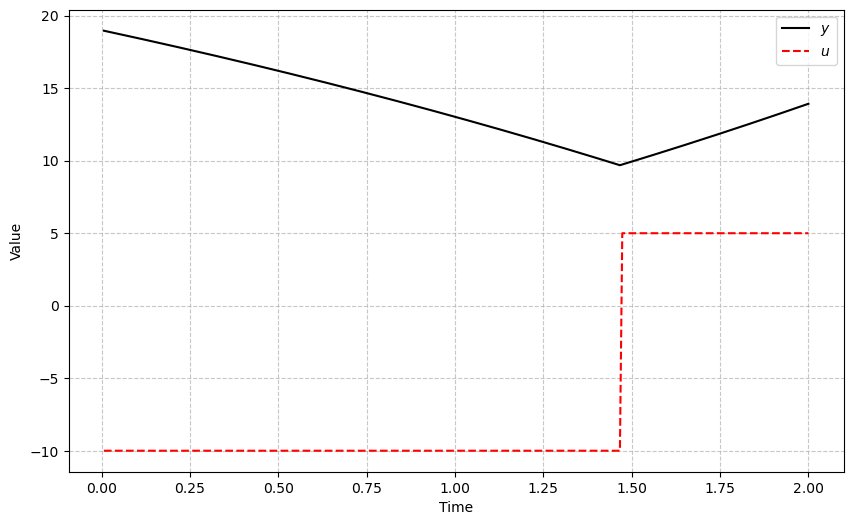

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(m.time[1:], y.value[1:], 'k-', label=r'$y$')
plt.plot(m.time[1:],u.value[1:],'r--',label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Здача_2_минимум.png')

# Задача 6


In [10]:
x0 = float(input('x0: '))
v0 = float(input('v0: '))

x0:  25
v0:  5


In [11]:
model = GEKKO(remote=False)

temperature = model.FV(value=1.0, lb=0.1, ub=100.0)
temperature.STATUS = 1

num_points = 51
model.time = np.linspace(0, 1, num_points)

pressure = np.zeros(num_points)
pressure[-1] = 1.0
final_pressure = model.Param(value=pressure)

position = model.Var(value=x0)
velocity = model.Var(value=v0)
control_input = model.MV(value=0, lb=-1, ub=1)
control_input.STATUS = 1

model.Equation(position.dt() == temperature * velocity)
model.Equation(velocity.dt() == temperature * control_input)

model.Equation(position * final_pressure == 0)
model.Equation(velocity * final_pressure == 0)

model.Obj(temperature)
model.options.IMODE = 6

In [12]:
model.solve(disp=False)

time_scaled = model.time * temperature.value[0]
position_solution, velocity_solution, control_input_solution = position.value, velocity.value, control_input.value

print(f'Минимальное T: {str(temperature.value[0])}')

Минимальное T: 17.111033745


In [13]:
control_input_solution[0] = control_input_solution[1]

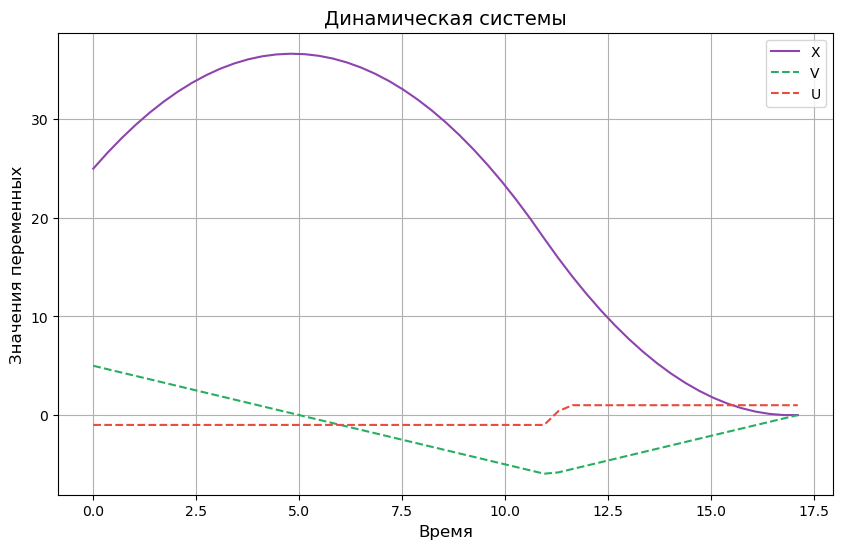

In [14]:
fig, ax = plt.subplots(figsize=(10, 6)) 

ax.plot(time_scaled, position_solution, '-', color='#8e44ad', label='Х')  
ax.plot(time_scaled, velocity_solution, '--', color='#27ae60', label='V')   
ax.plot(time_scaled, control_input_solution, '--', color='#e74c3c', label='U')  

ax.legend(loc='best')
ax.set_xlabel('Время', fontsize=12)
ax.set_ylabel('Значения переменных', fontsize=12)
ax.set_title('Динамическая системы', fontsize=14)
ax.grid(True)

plt.show()

# Задача 7

## a) $y' = u - t$

In [21]:
# Устанавливаем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=0) 
z = m.Var(value=5) 
u = m.Var(value=0,lb=-3/8, ub=3/8)
t = m.Var(value=0)
p = np.zeros(nt)   
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == u - t)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == 0.5 * (u ** 2) - t * y + y)
m.Obj(z * final) # Целевая функция (ищем минимум)
m.options.IMODE = 6
m.solve()

 ----------------------------------------------------------------
 APMonitor, Version 1.0.3
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :  0
   Constants    :  0
   Variables    :  5
   Intermediates:  0
   Connections  :  0
   Equations    :  4
   Residuals    :  4
 
 Number of state variables:    2100
 Number of total equations: -  1800
 Number of slack variables: -  0
 ---------------------------------------
 Degrees of freedom       :    300
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
       

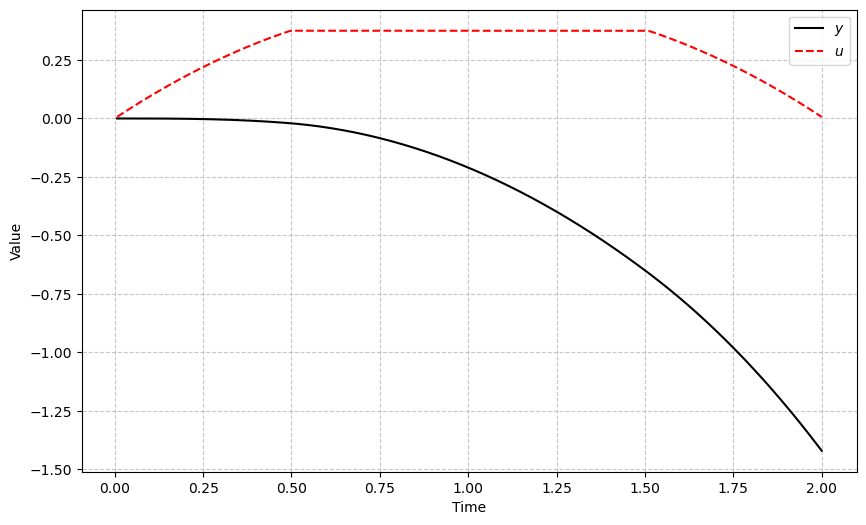

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(m.time[1:], y.value[1:], 'k-', label=r'$y$')
plt.plot(m.time[1:],u.value[1:],'r--',label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Задача_7_a')

In [23]:
print(f"Значение функционала: {m.options.OBJFCNVAL}")

Значение функционала: 5.5444727291


## b) $y'(t) = u(t) + u^2(t) - t$

In [24]:
# Устанавливаем модель
m = GEKKO(remote=False)
nt = 301
m.time = np.linspace(0, 2, nt)

# Задаём переменные
y = m.Var(value=0) 
z = m.Var(value=5) 
u = m.Var(value=0,lb=-3/8, ub=3/8)
t = m.Var(value=0)
p = np.zeros(nt)   
p[-1] = 1.0
final = m.Param(value=p)

# Задаём уравнения
m.Equation(y.dt() == u + (u ** 2) - t)
m.Equation(t.dt() == 1)
m.Equation(z.dt() == 0.5 * (u ** 2) - t * y + y)
m.Obj(z * final) # Целевая функция (ищем минимум)
m.options.IMODE = 6
m.solve()

 ----------------------------------------------------------------
 APMonitor, Version 1.0.3
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :  0
   Constants    :  0
   Variables    :  5
   Intermediates:  0
   Connections  :  0
   Equations    :  4
   Residuals    :  4
 
 Number of state variables:    2100
 Number of total equations: -  1800
 Number of slack variables: -  0
 ---------------------------------------
 Degrees of freedom       :    300
 
 **********************************************
 Dynamic Control with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
       

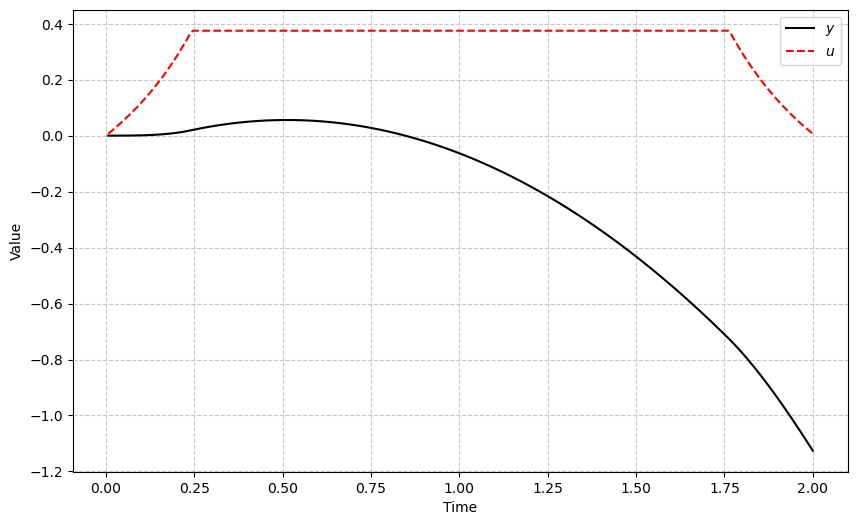

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(m.time[1:], y.value[1:], 'k-', label=r'$y$')
plt.plot(m.time[1:],u.value[1:],'r--',label=r'$u$')
plt.legend(loc='best')
plt.xlabel('Time')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Задача_7_пункт_b')

In [26]:
print(f"Значение функционала: {m.options.OBJFCNVAL}")

Значение функционала: 5.4574082484


# Задача 8

Гамма: 0.1, Альфа: 0.2, Бета: 0.1


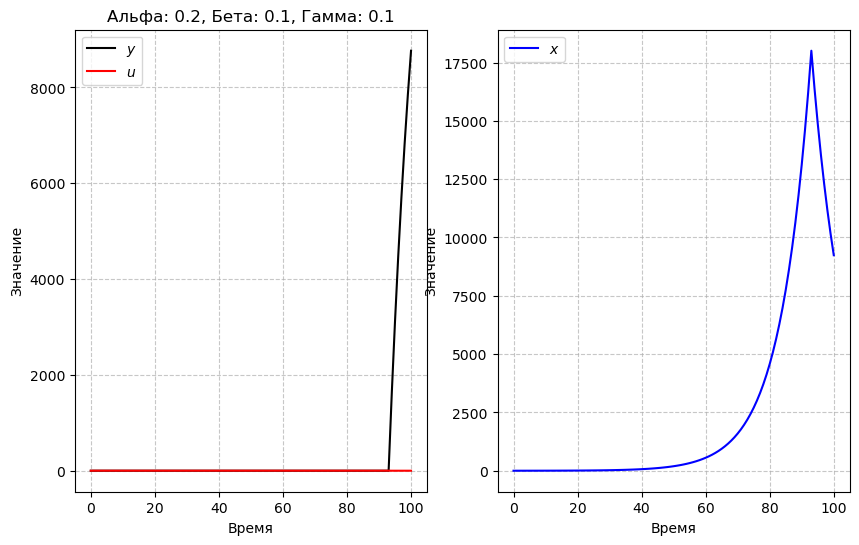

Гамма: 0.1, Альфа: 0.2, Бета: 0.4


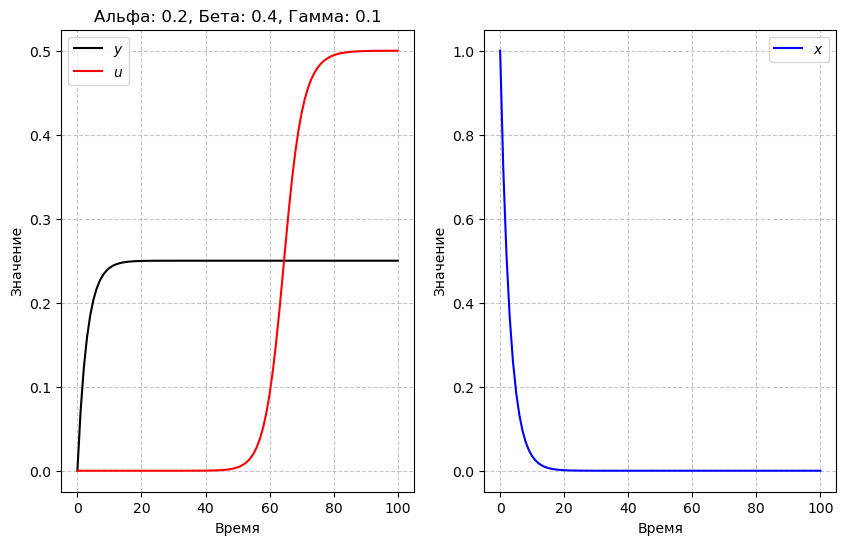

Гамма: 0.1, Альфа: 0.2, Бета: 0.7


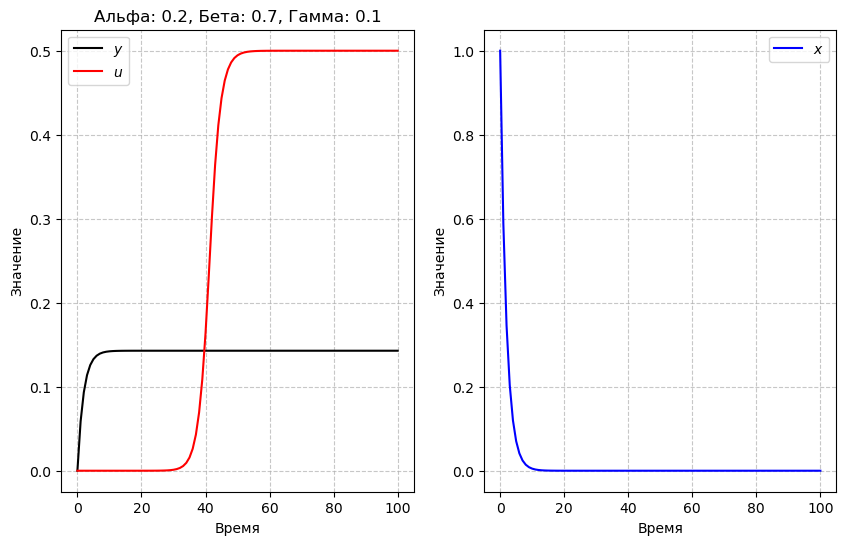

Гамма: 0.1, Альфа: 0.2, Бета: 0.9


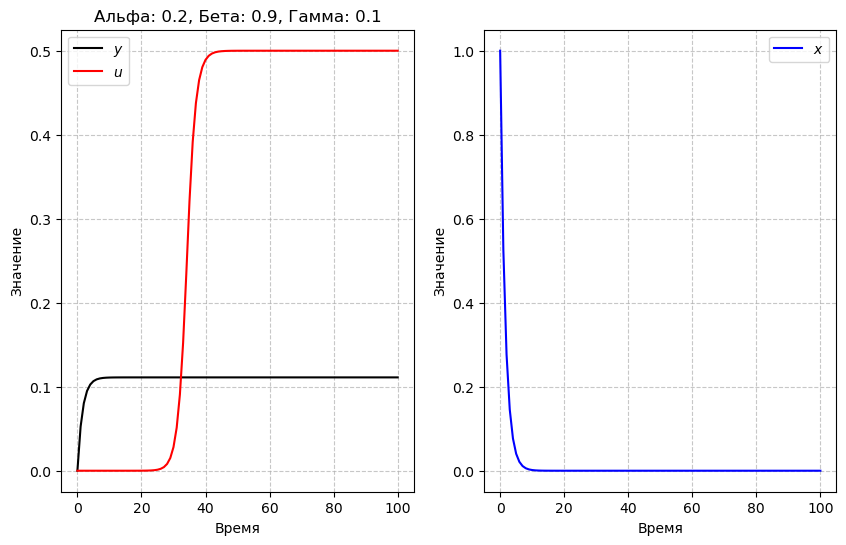

Гамма: 0.1, Альфа: 0.4, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.1, Альфа: 0.4, Бета: 0.4


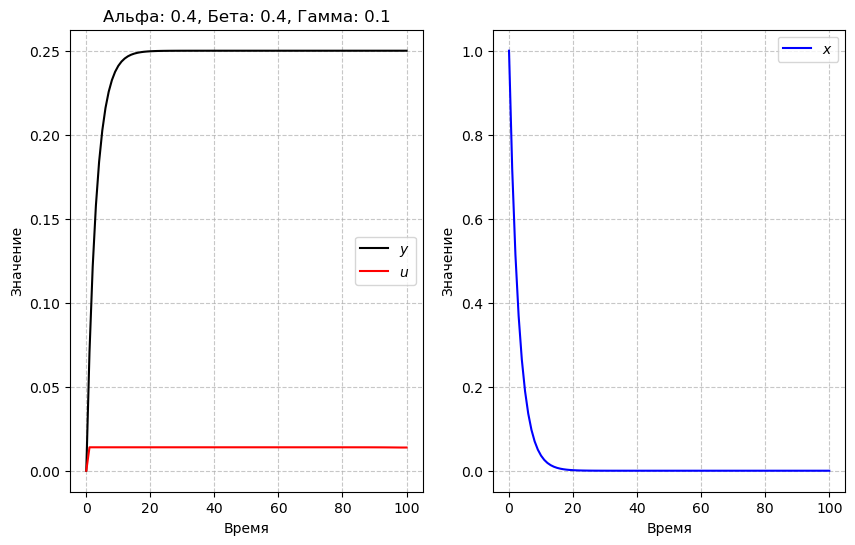

Гамма: 0.1, Альфа: 0.4, Бета: 0.7


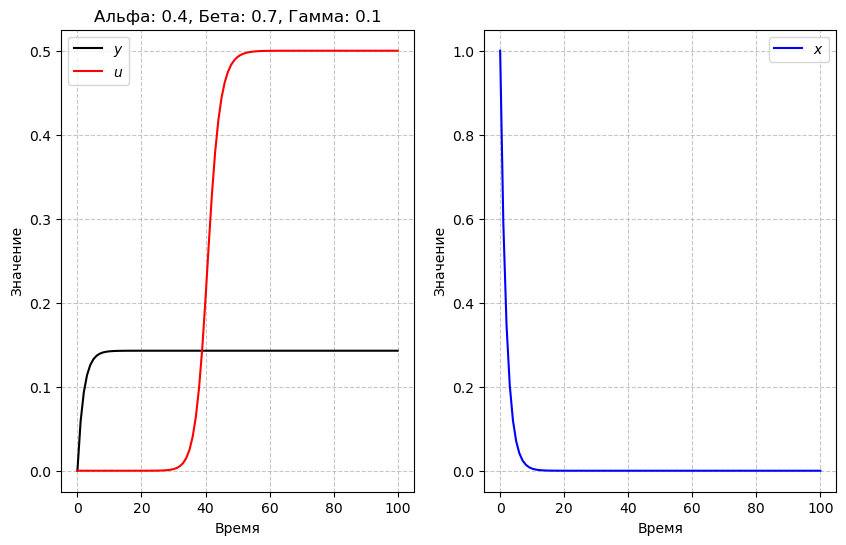

Гамма: 0.1, Альфа: 0.4, Бета: 0.9


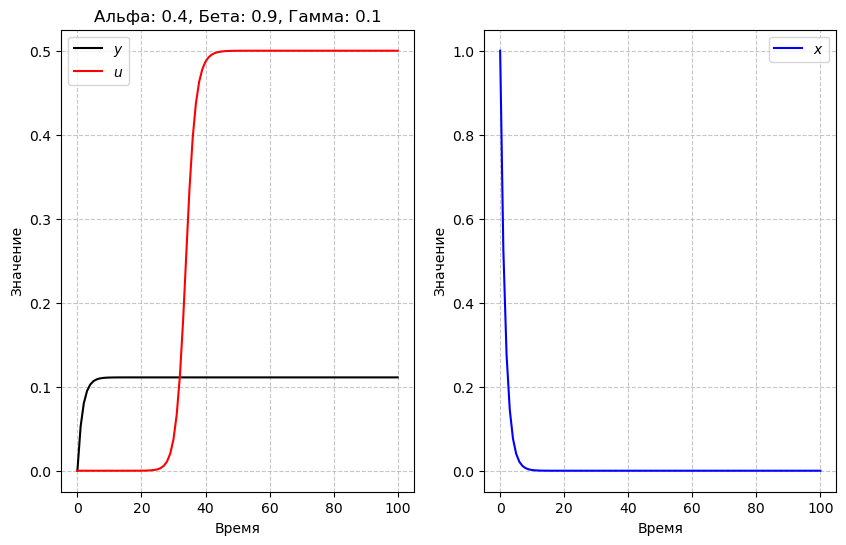

Гамма: 0.1, Альфа: 0.6, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.1, Альфа: 0.6, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.1, Альфа: 0.6, Бета: 0.7


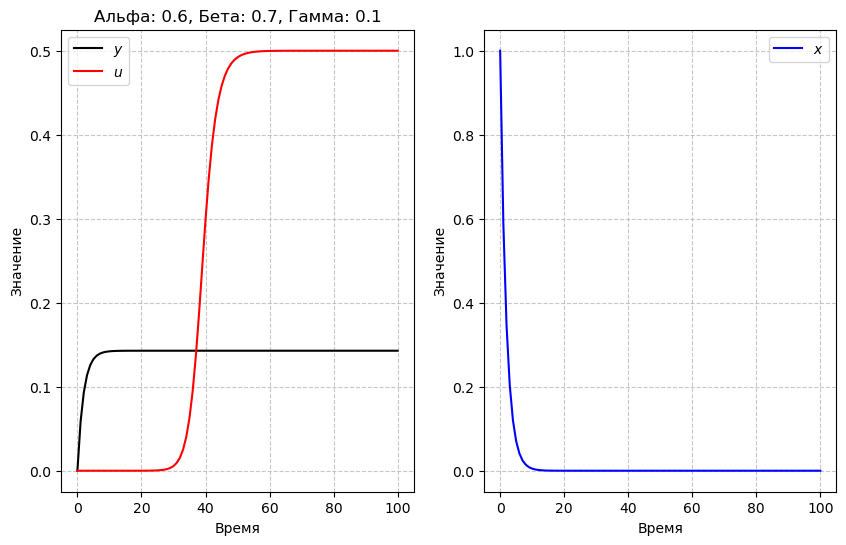

Гамма: 0.1, Альфа: 0.6, Бета: 0.9


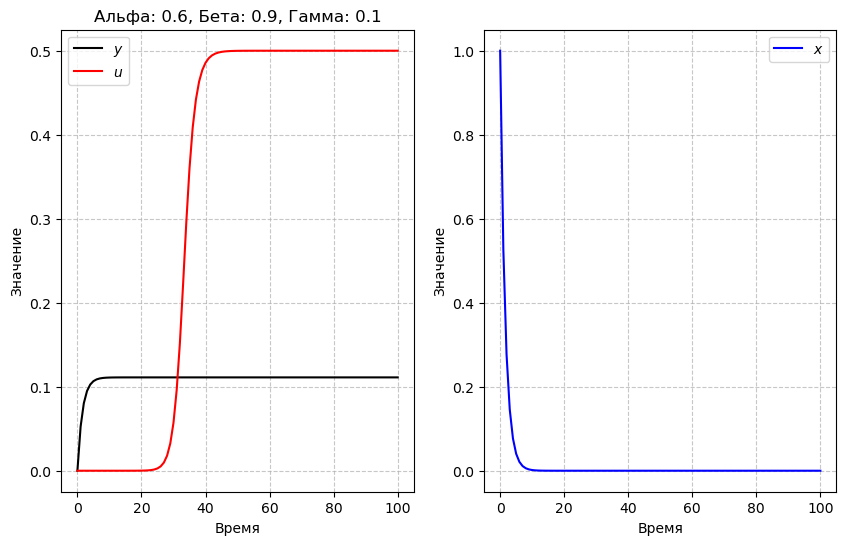

Гамма: 0.1, Альфа: 0.8, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.1, Альфа: 0.8, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.1, Альфа: 0.8, Бета: 0.7


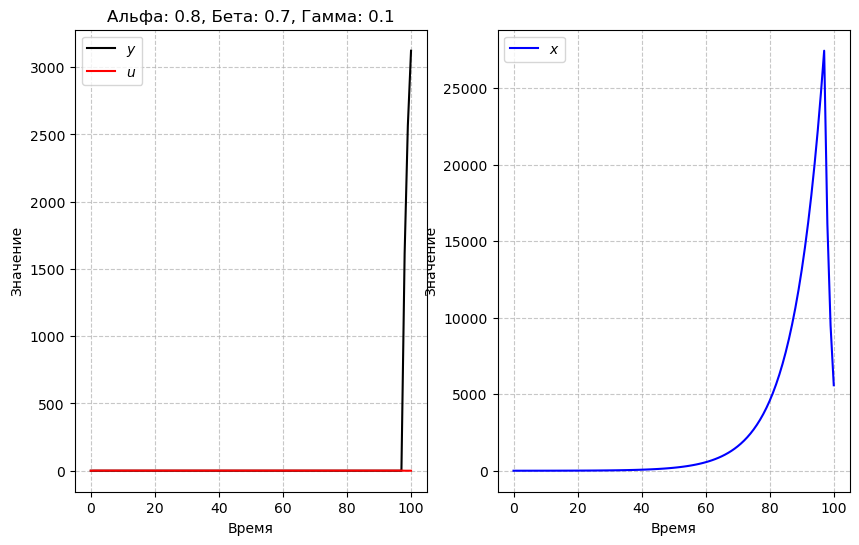

Гамма: 0.1, Альфа: 0.8, Бета: 0.9


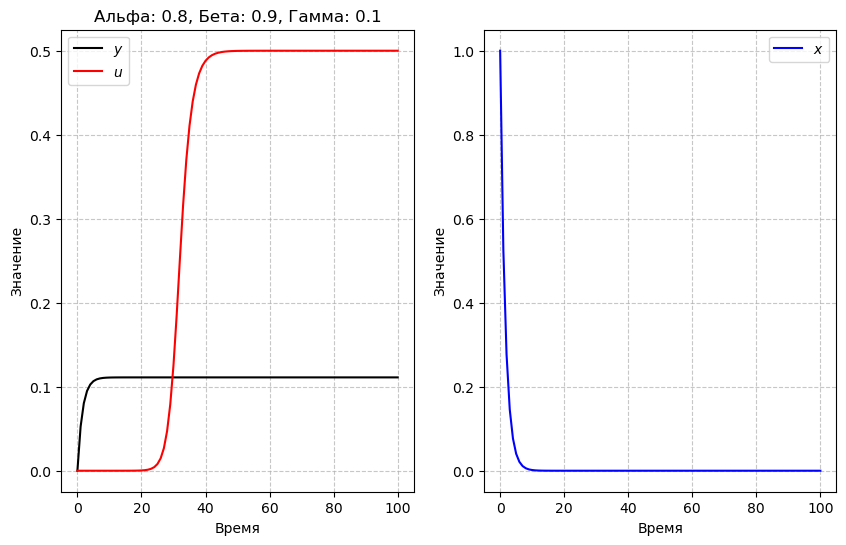

Гамма: 0.3, Альфа: 0.2, Бета: 0.1


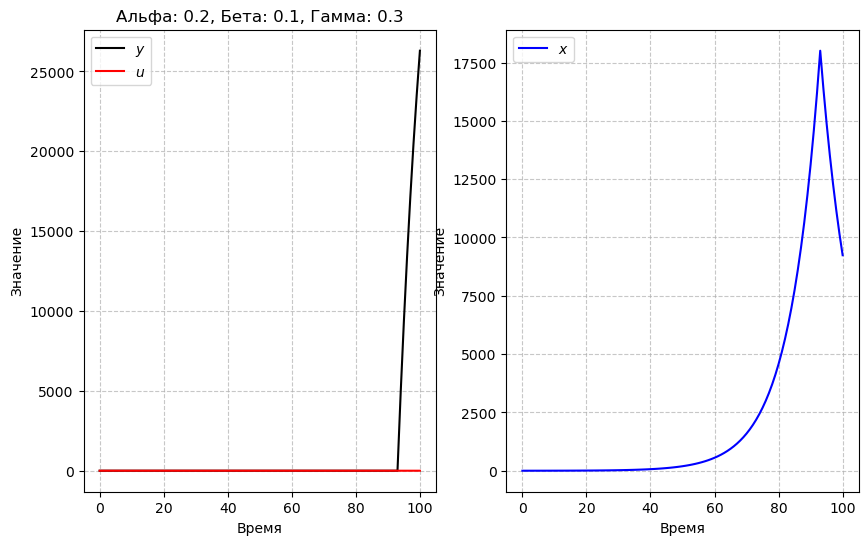

Гамма: 0.3, Альфа: 0.2, Бета: 0.4


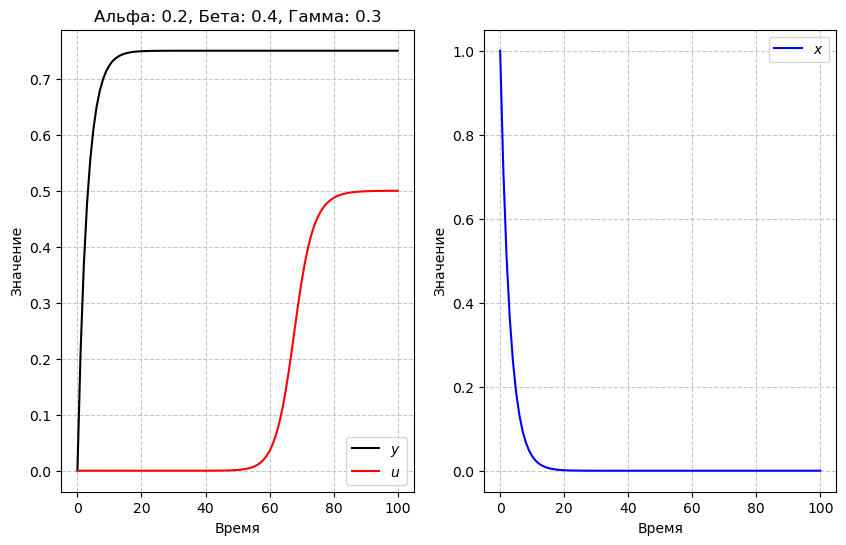

Гамма: 0.3, Альфа: 0.2, Бета: 0.7


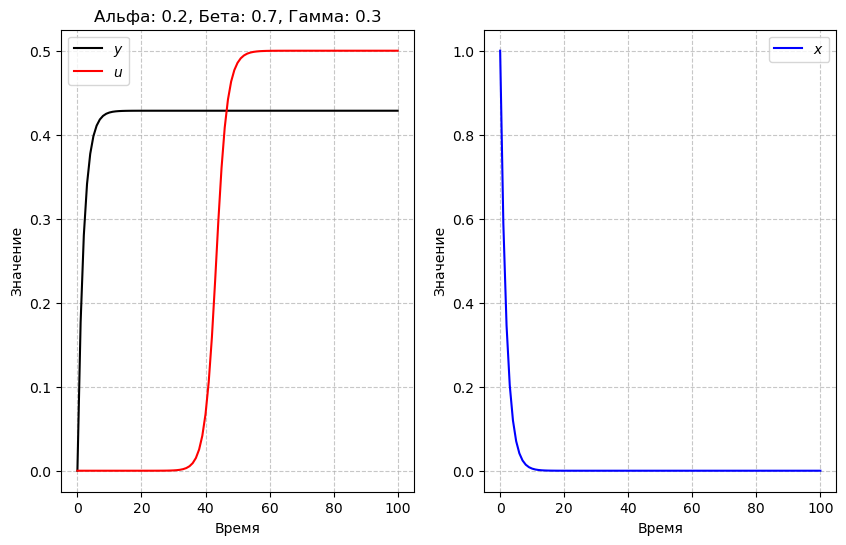

Гамма: 0.3, Альфа: 0.2, Бета: 0.9


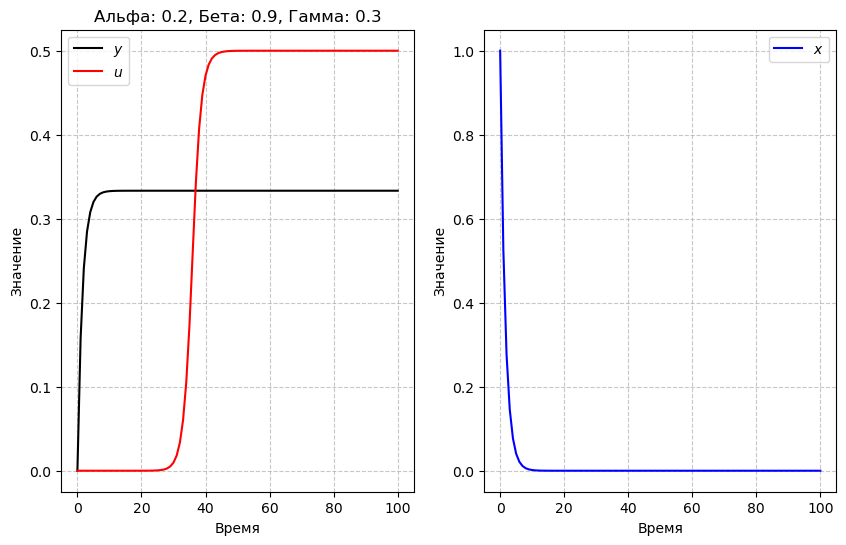

Гамма: 0.3, Альфа: 0.4, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.3, Альфа: 0.4, Бета: 0.4


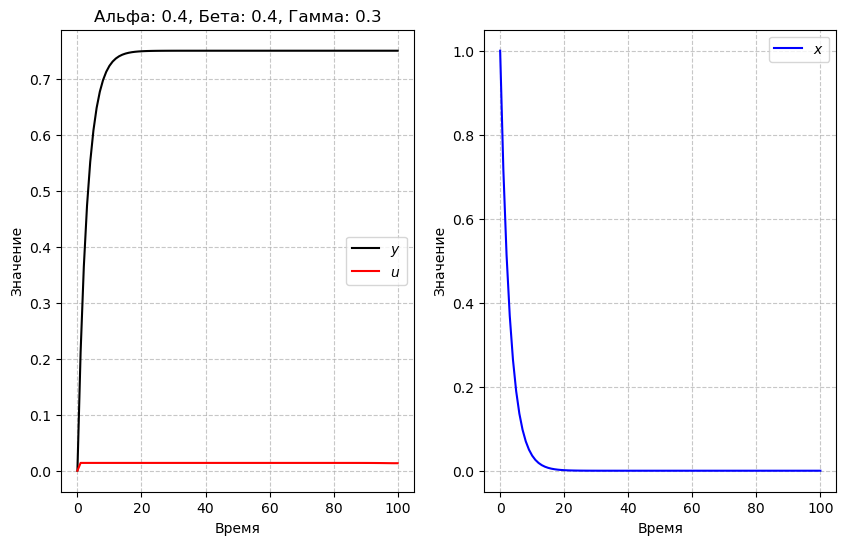

Гамма: 0.3, Альфа: 0.4, Бета: 0.7


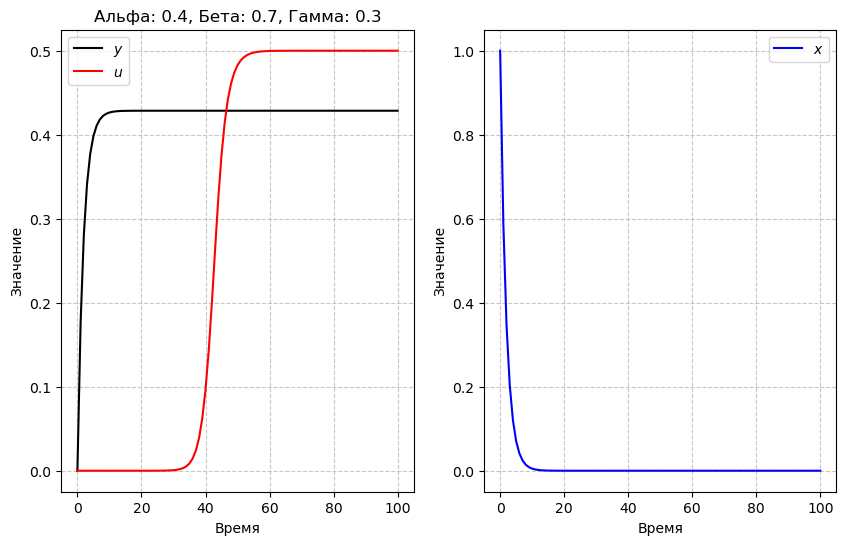

Гамма: 0.3, Альфа: 0.4, Бета: 0.9


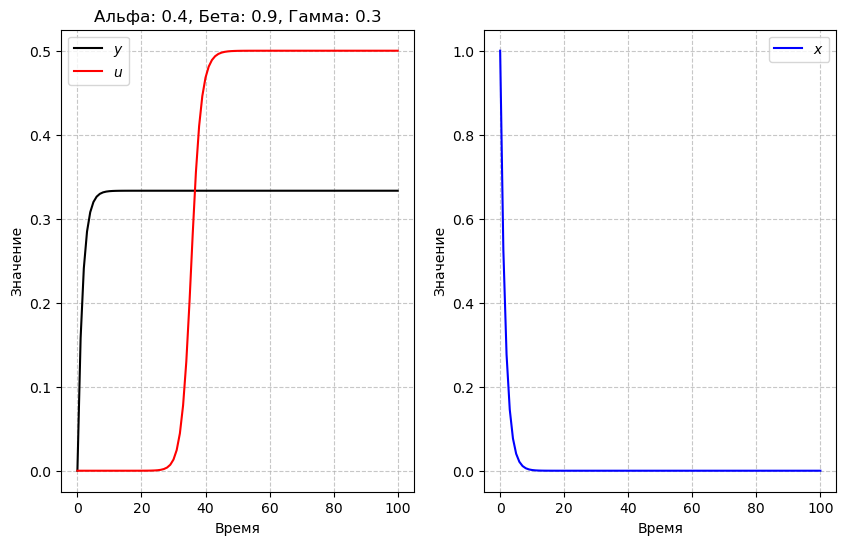

Гамма: 0.3, Альфа: 0.6, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.3, Альфа: 0.6, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.3, Альфа: 0.6, Бета: 0.7


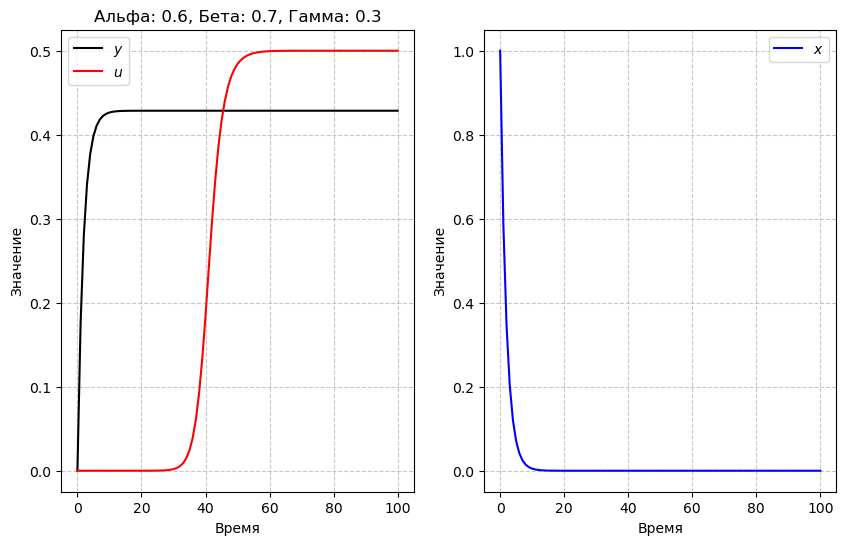

Гамма: 0.3, Альфа: 0.6, Бета: 0.9


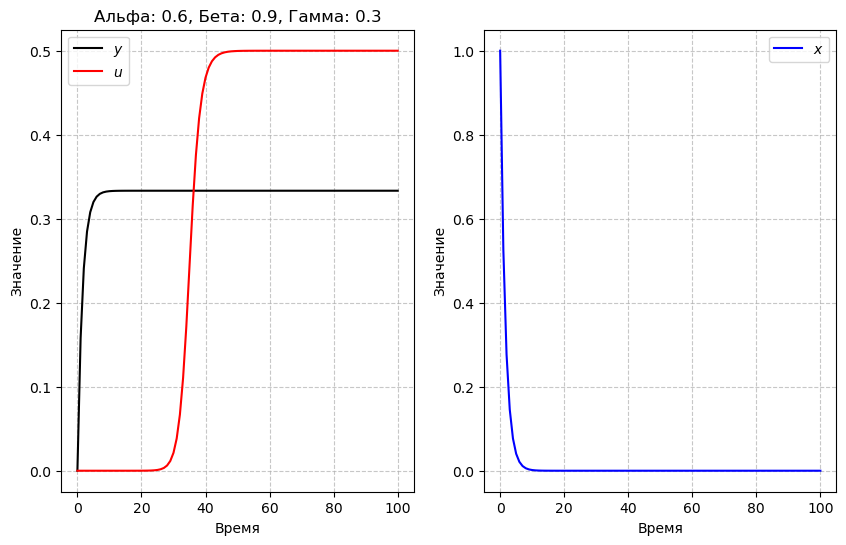

Гамма: 0.3, Альфа: 0.8, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.3, Альфа: 0.8, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.3, Альфа: 0.8, Бета: 0.7


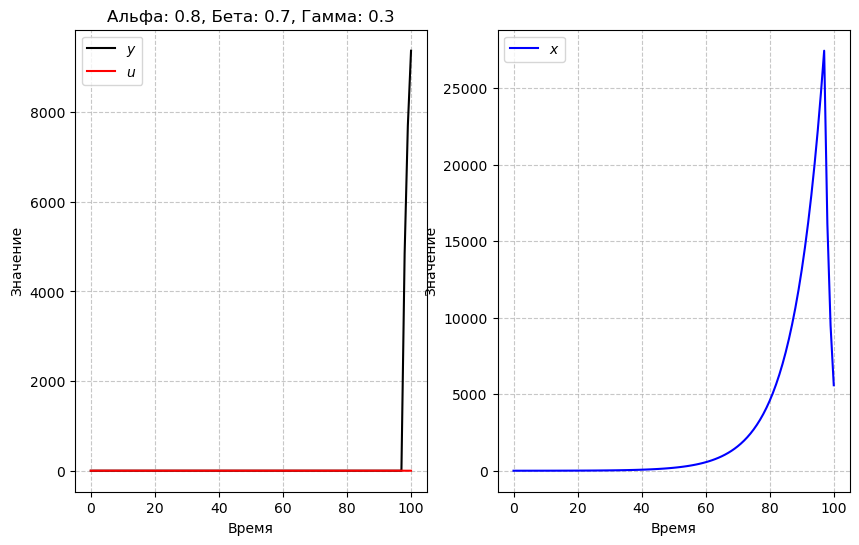

Гамма: 0.3, Альфа: 0.8, Бета: 0.9


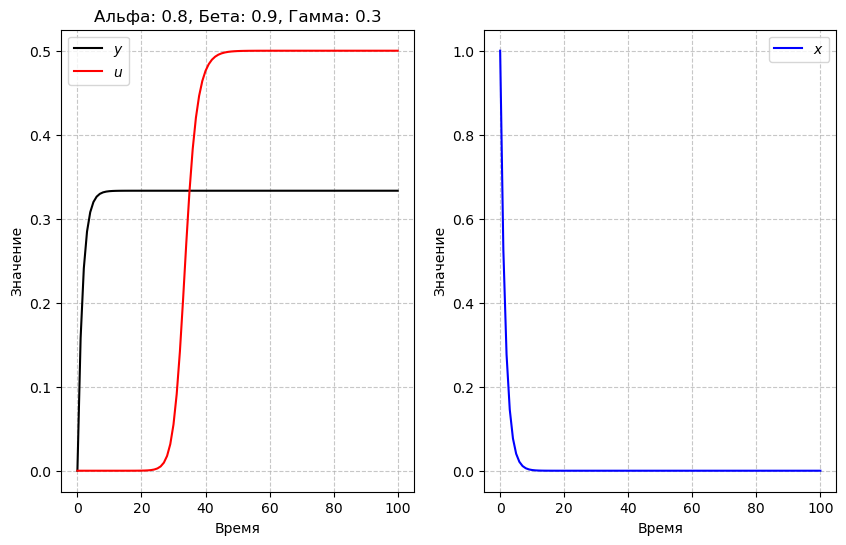

Гамма: 0.7, Альфа: 0.2, Бета: 0.1


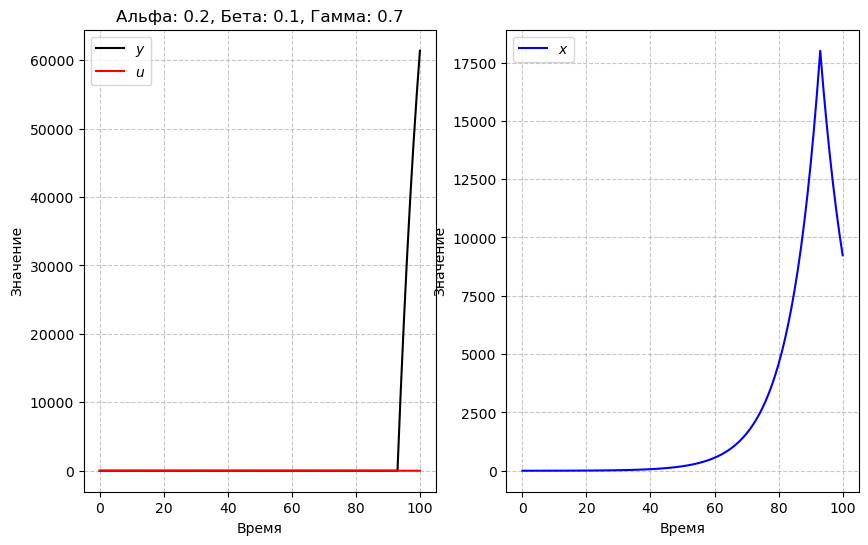

Гамма: 0.7, Альфа: 0.2, Бета: 0.4


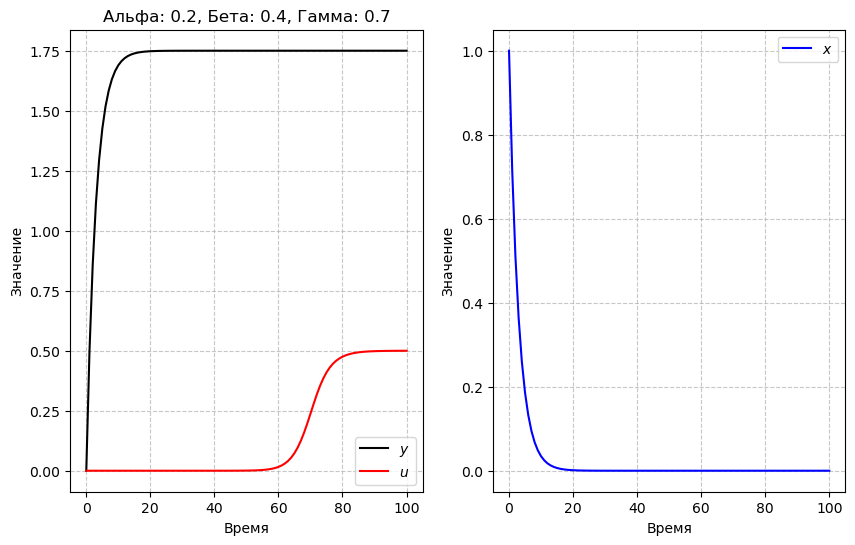

Гамма: 0.7, Альфа: 0.2, Бета: 0.7


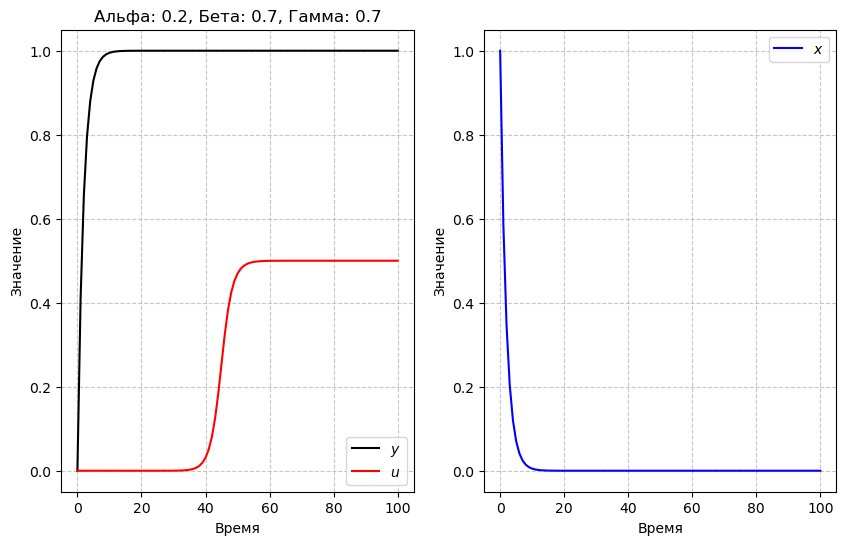

Гамма: 0.7, Альфа: 0.2, Бета: 0.9


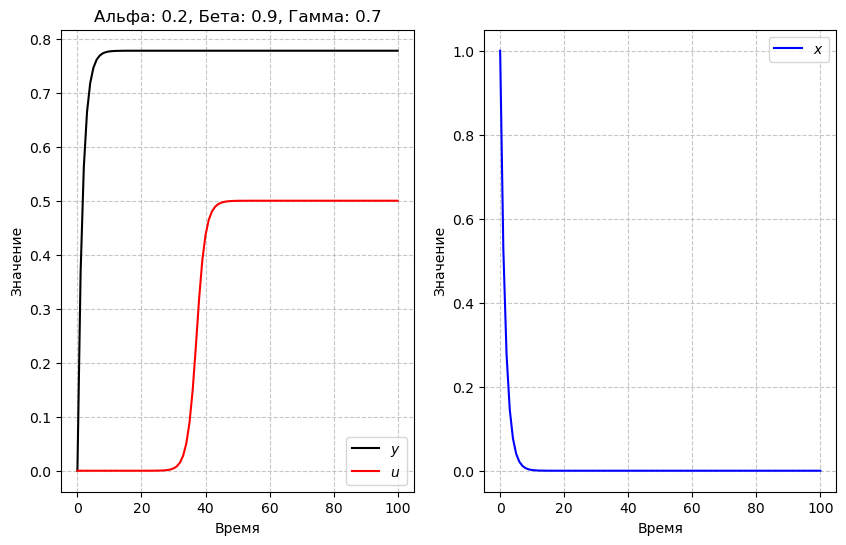

Гамма: 0.7, Альфа: 0.4, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.7, Альфа: 0.4, Бета: 0.4


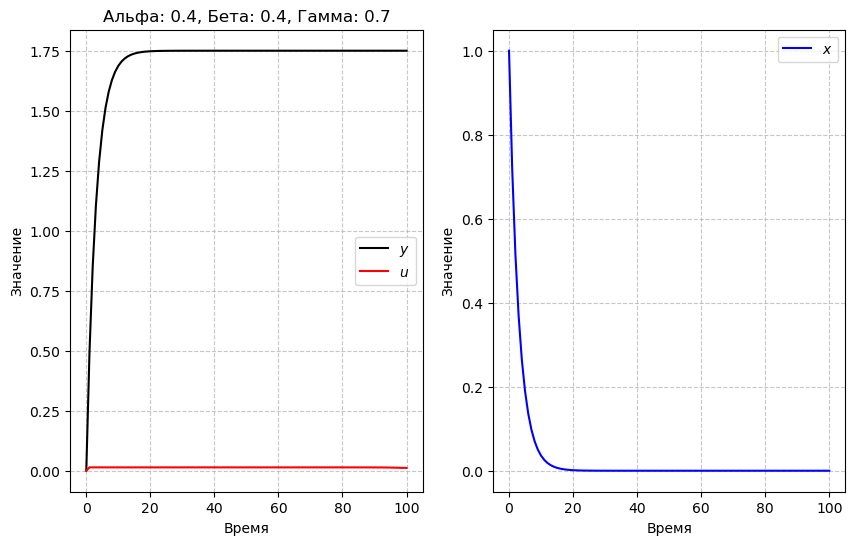

Гамма: 0.7, Альфа: 0.4, Бета: 0.7


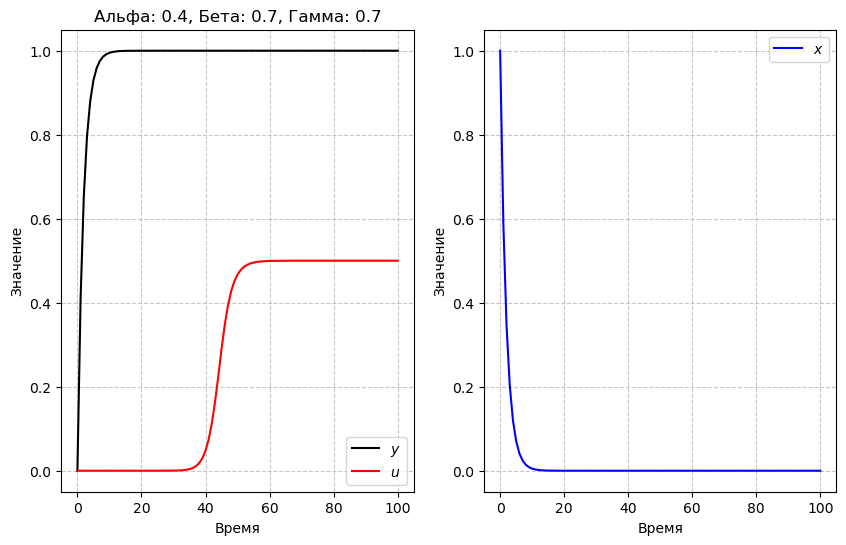

Гамма: 0.7, Альфа: 0.4, Бета: 0.9


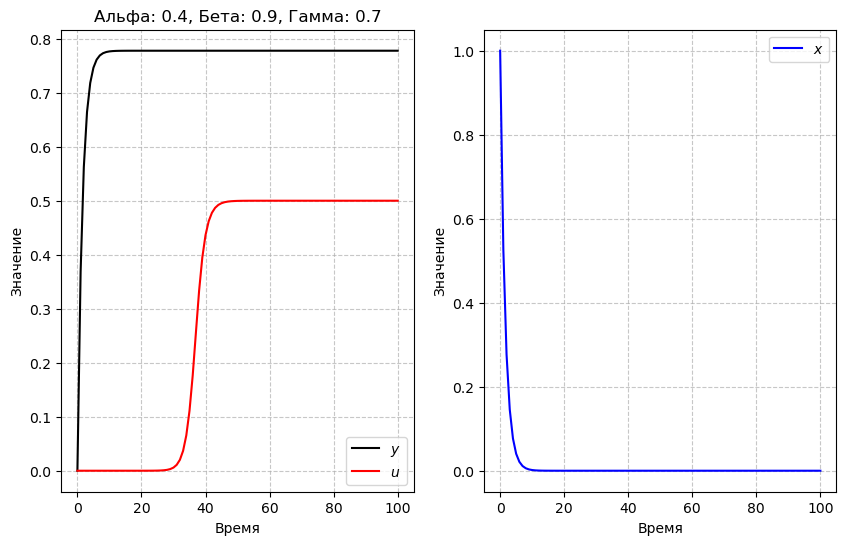

Гамма: 0.7, Альфа: 0.6, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.7, Альфа: 0.6, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.7, Альфа: 0.6, Бета: 0.7


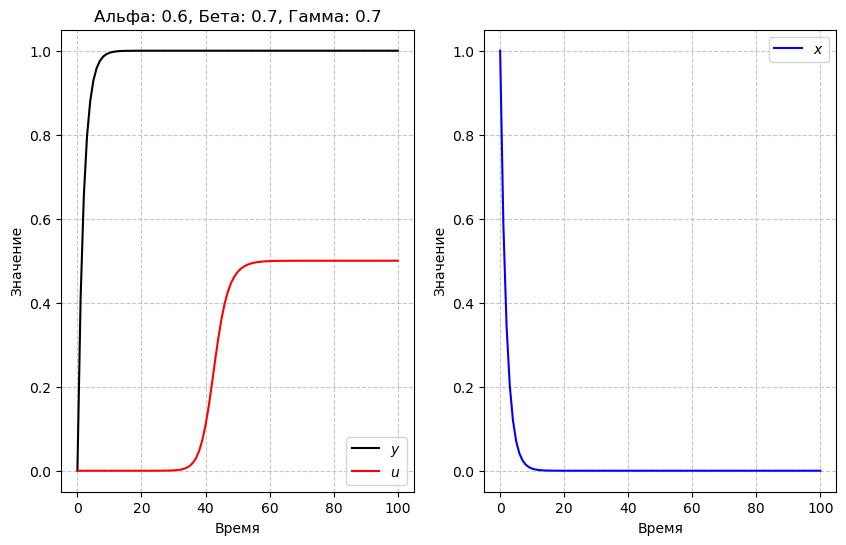

Гамма: 0.7, Альфа: 0.6, Бета: 0.9


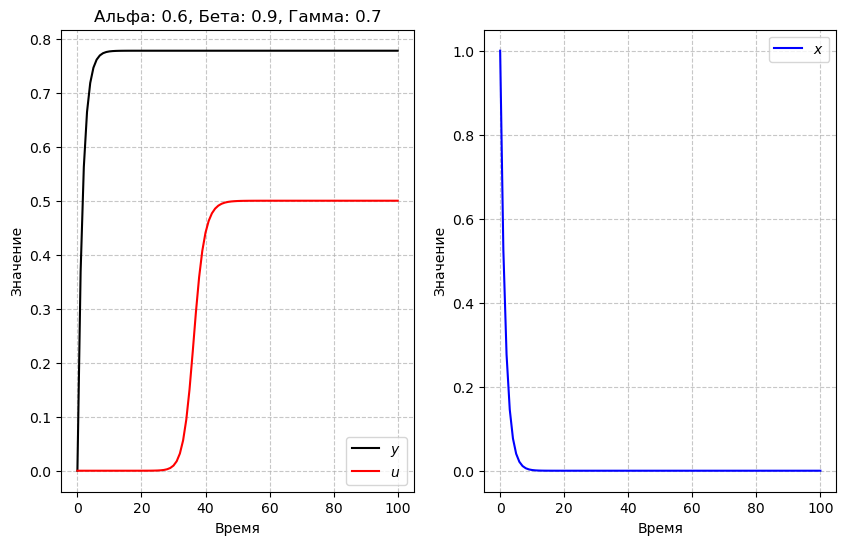

Гамма: 0.7, Альфа: 0.8, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.7, Альфа: 0.8, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.7, Альфа: 0.8, Бета: 0.7


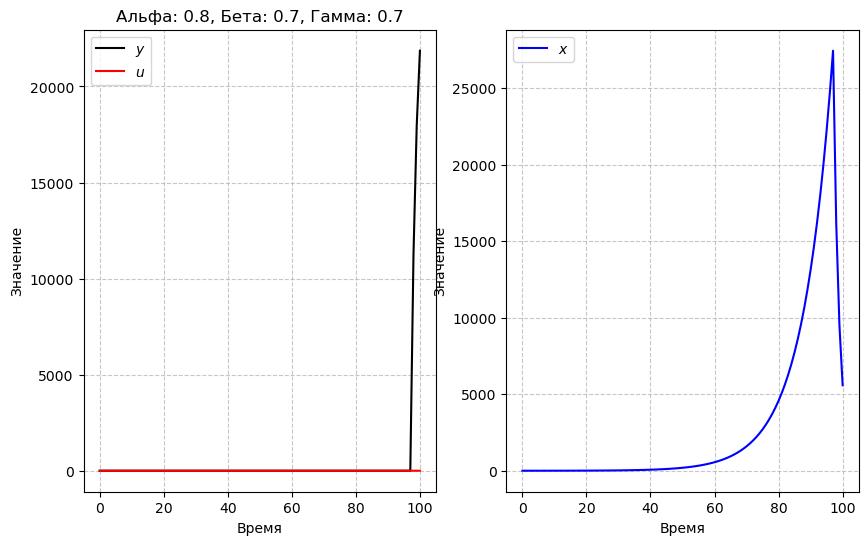

Гамма: 0.7, Альфа: 0.8, Бета: 0.9


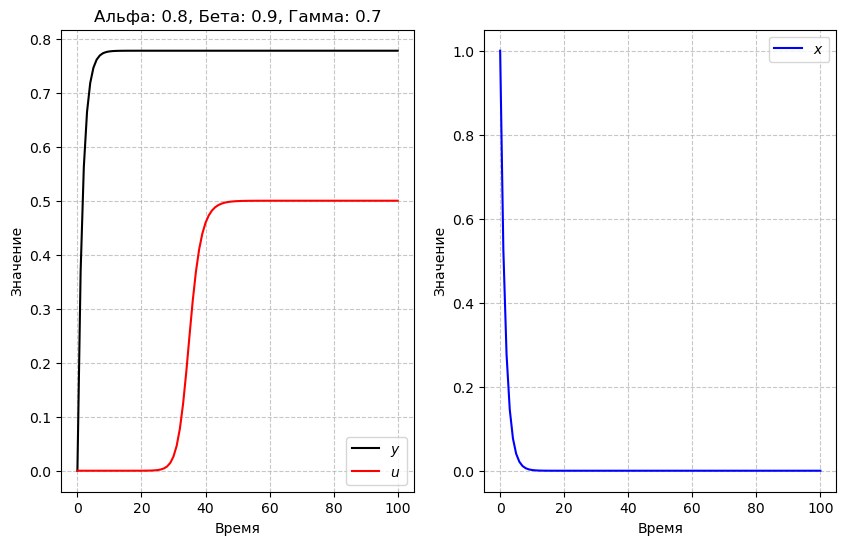

Гамма: 0.9, Альфа: 0.2, Бета: 0.1


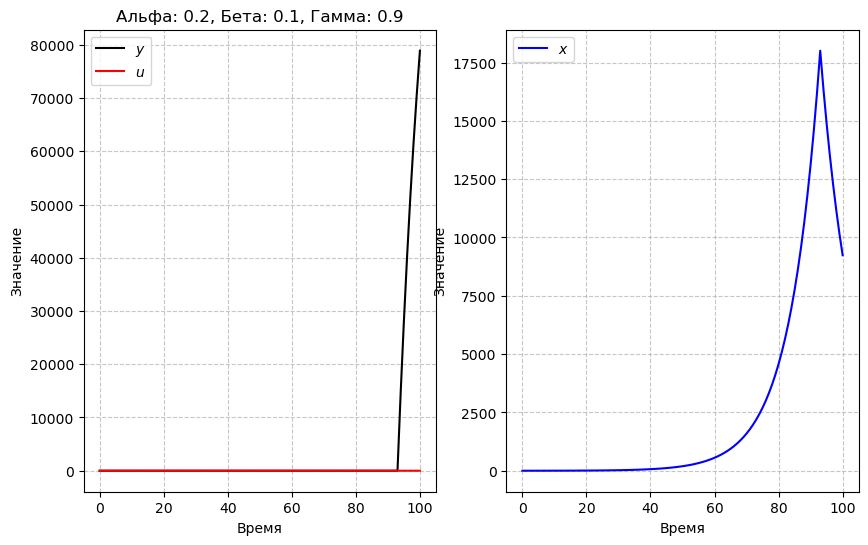

Гамма: 0.9, Альфа: 0.2, Бета: 0.4


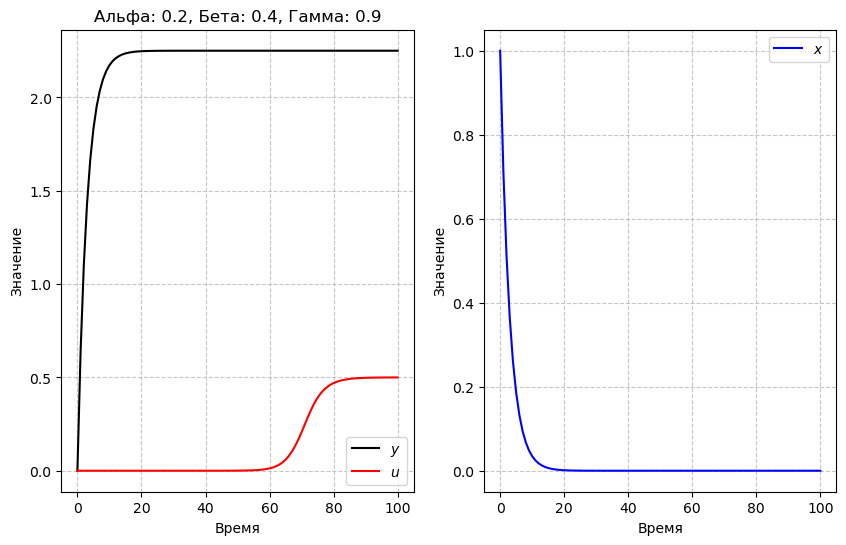

Гамма: 0.9, Альфа: 0.2, Бета: 0.7


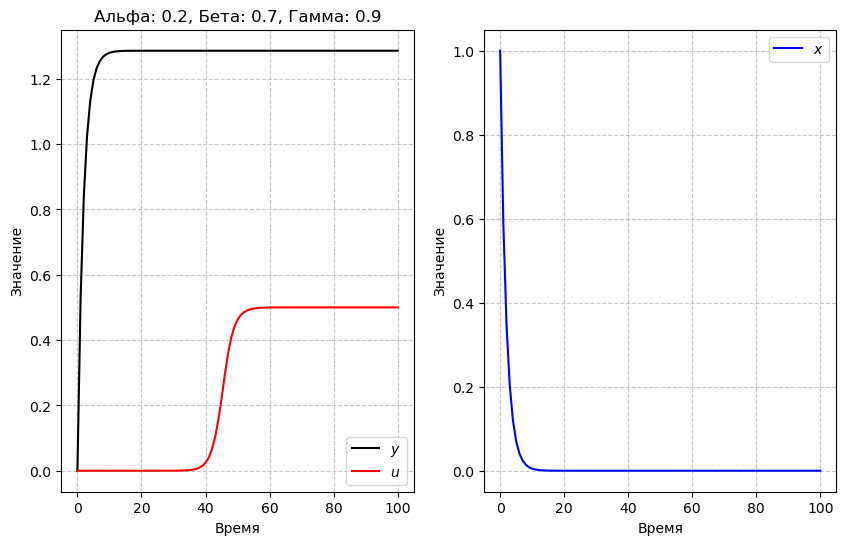

Гамма: 0.9, Альфа: 0.2, Бета: 0.9


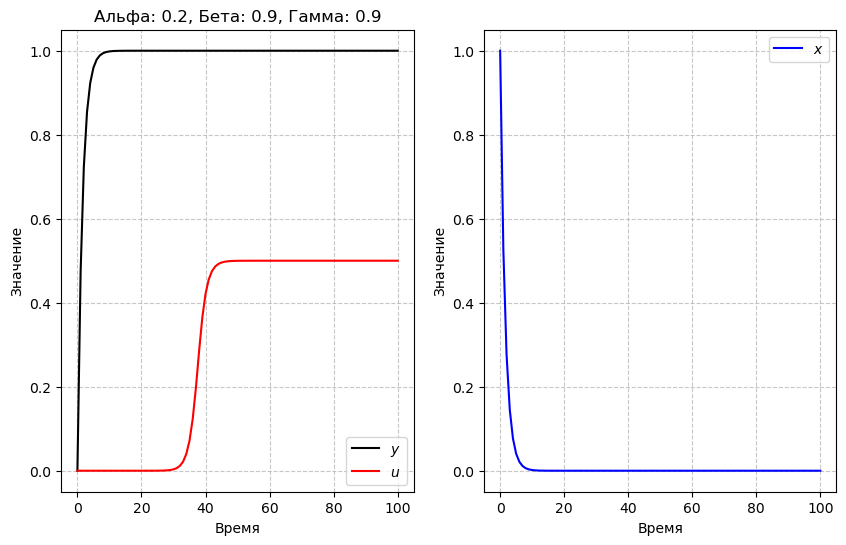

Гамма: 0.9, Альфа: 0.4, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.9, Альфа: 0.4, Бета: 0.4


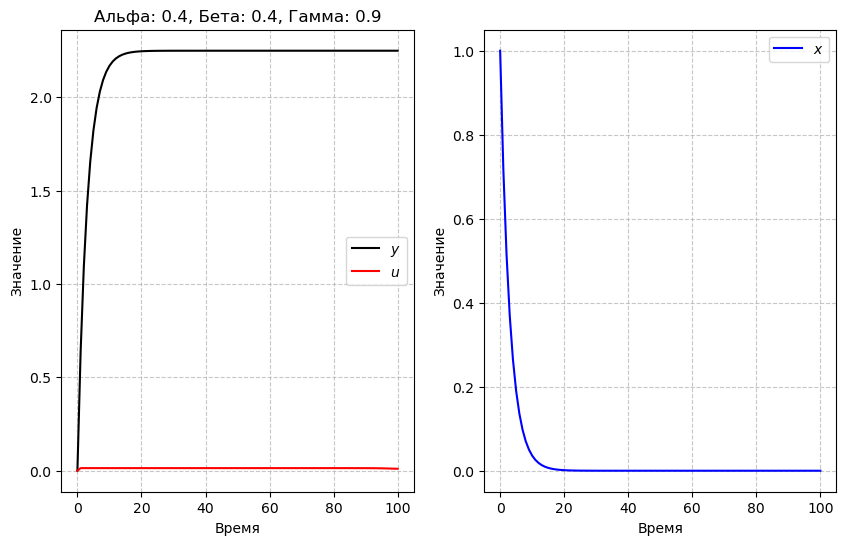

Гамма: 0.9, Альфа: 0.4, Бета: 0.7


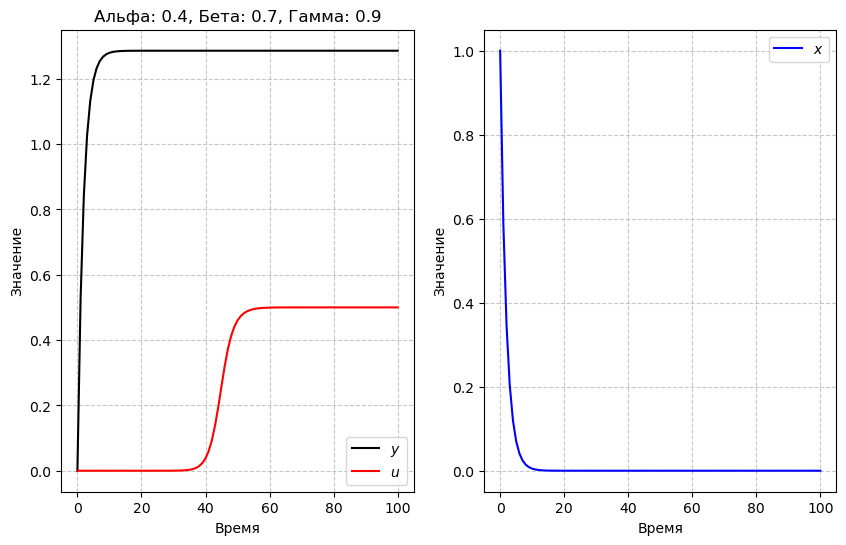

Гамма: 0.9, Альфа: 0.4, Бета: 0.9


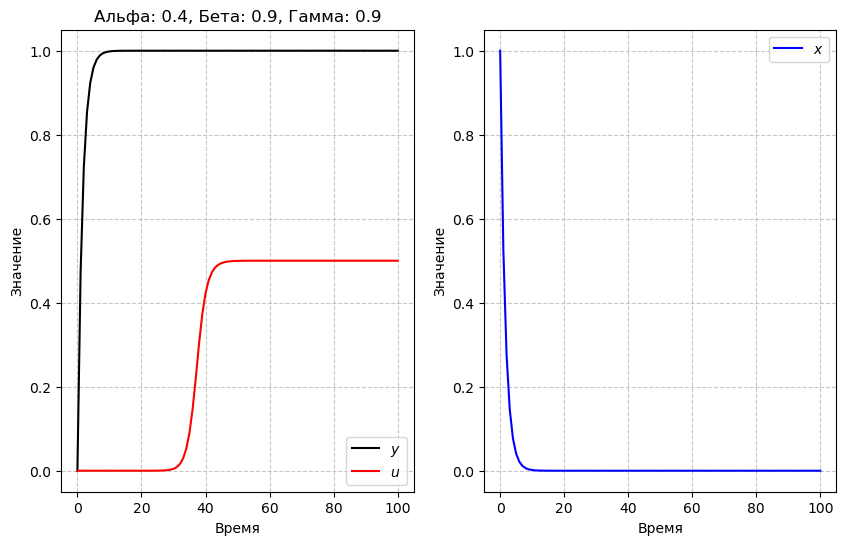

Гамма: 0.9, Альфа: 0.6, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.9, Альфа: 0.6, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.9, Альфа: 0.6, Бета: 0.7


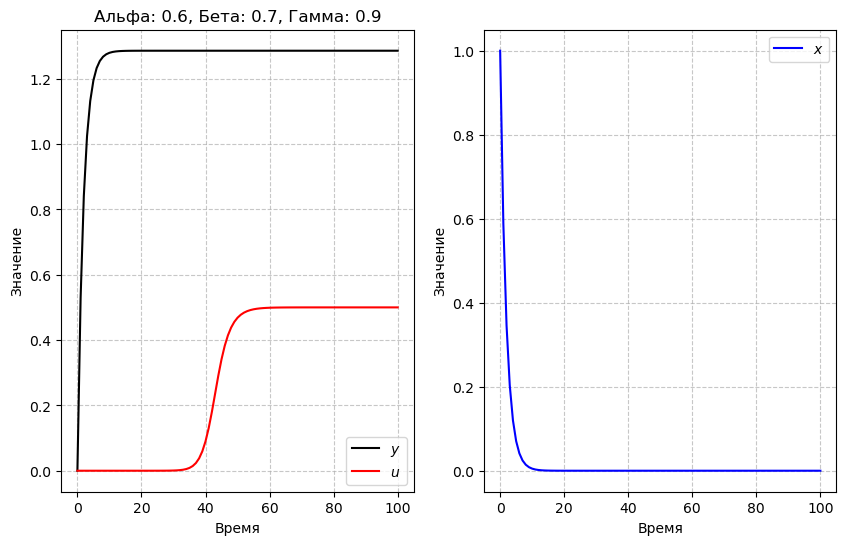

Гамма: 0.9, Альфа: 0.6, Бета: 0.9


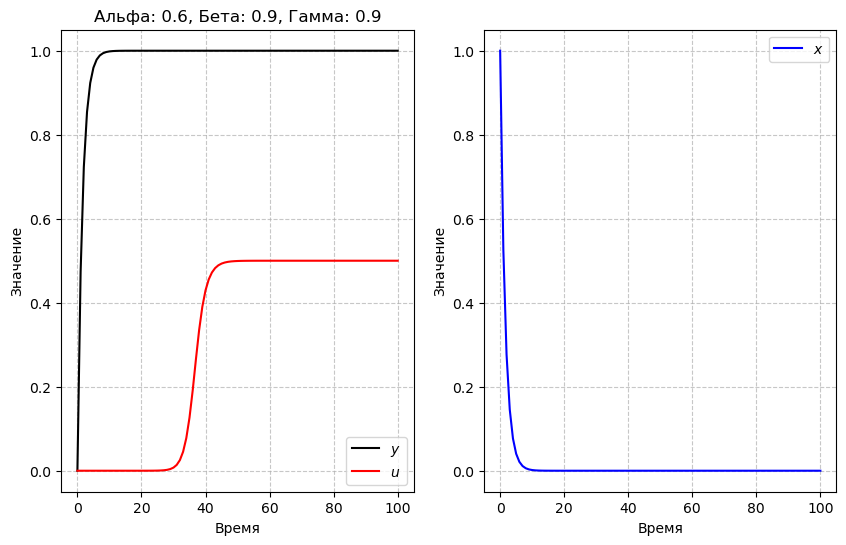

Гамма: 0.9, Альфа: 0.8, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 0.9, Альфа: 0.8, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 0.9, Альфа: 0.8, Бета: 0.7


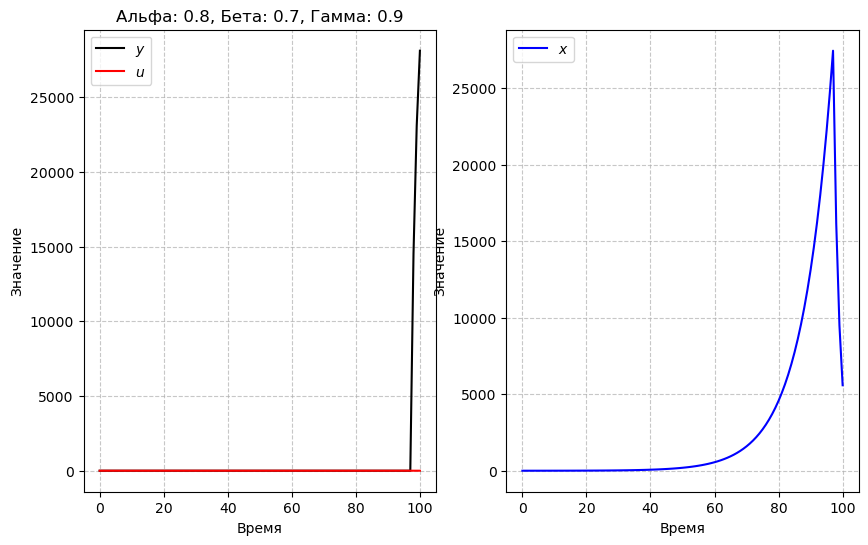

Гамма: 0.9, Альфа: 0.8, Бета: 0.9


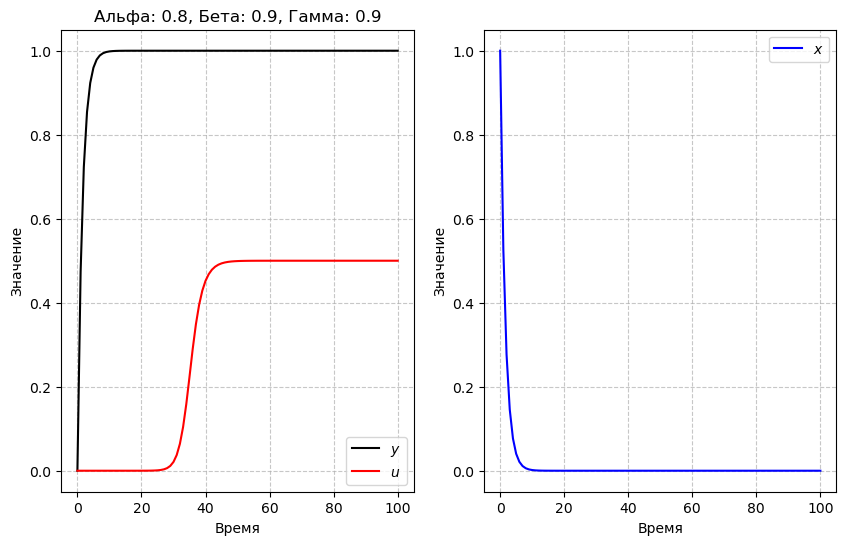

Гамма: 1, Альфа: 0.2, Бета: 0.1


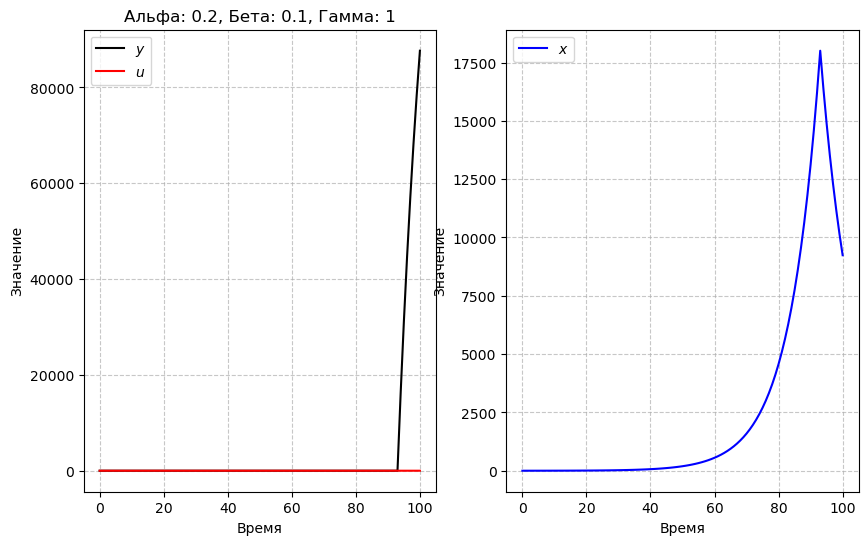

Гамма: 1, Альфа: 0.2, Бета: 0.4


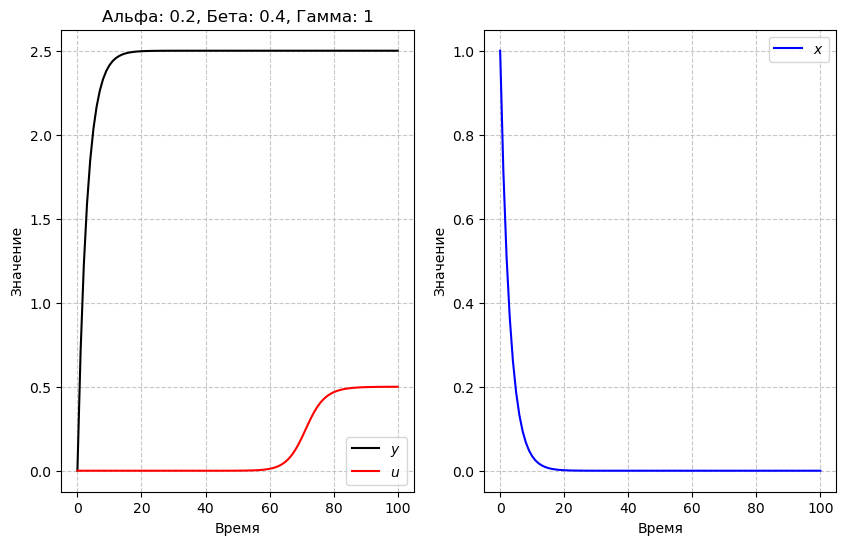

Гамма: 1, Альфа: 0.2, Бета: 0.7


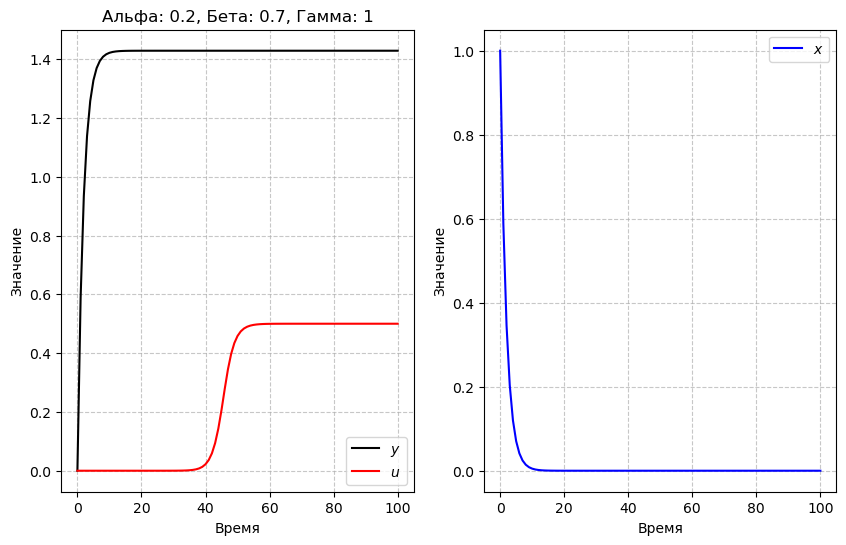

Гамма: 1, Альфа: 0.2, Бета: 0.9


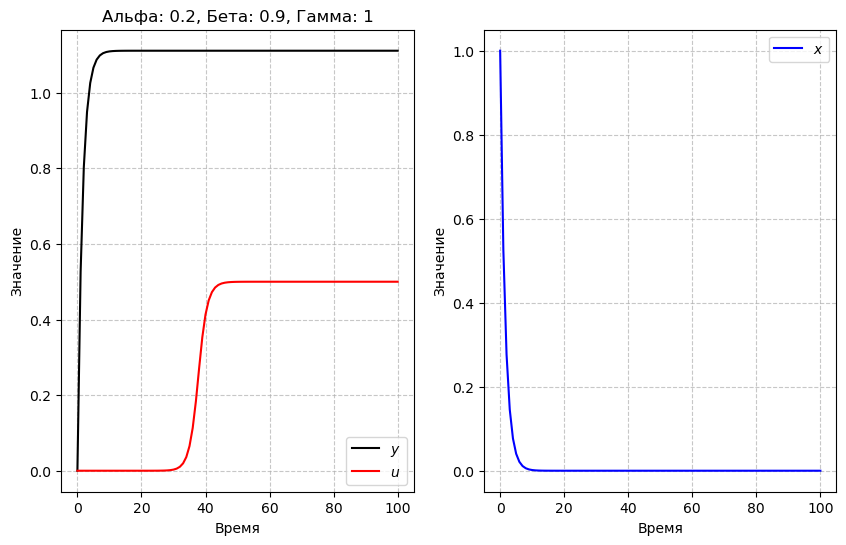

Гамма: 1, Альфа: 0.4, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 1, Альфа: 0.4, Бета: 0.4


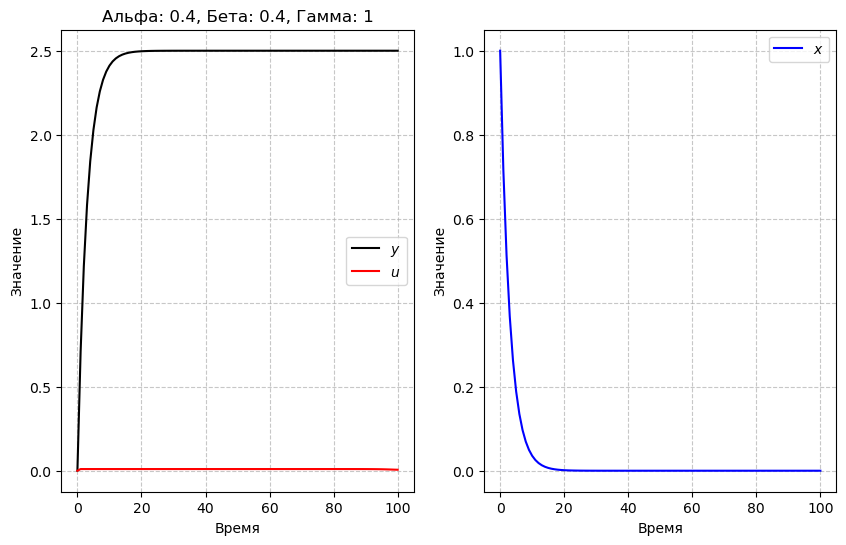

Гамма: 1, Альфа: 0.4, Бета: 0.7


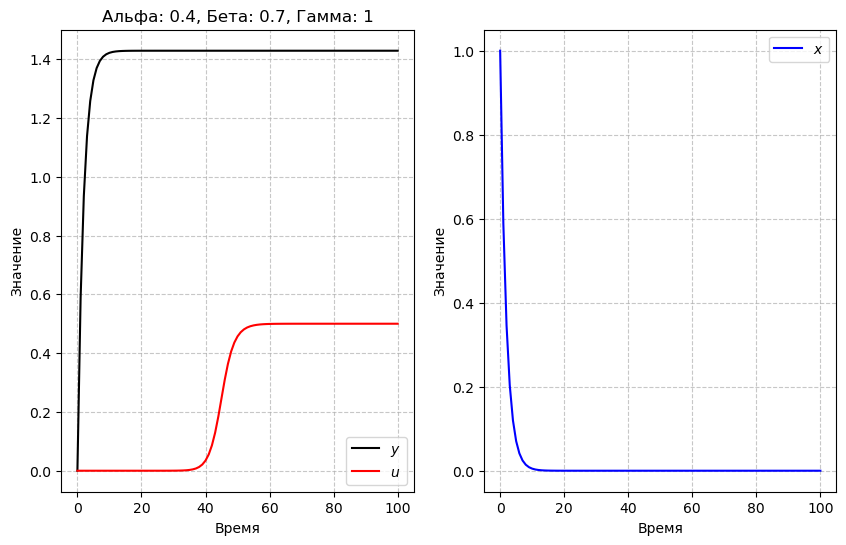

Гамма: 1, Альфа: 0.4, Бета: 0.9


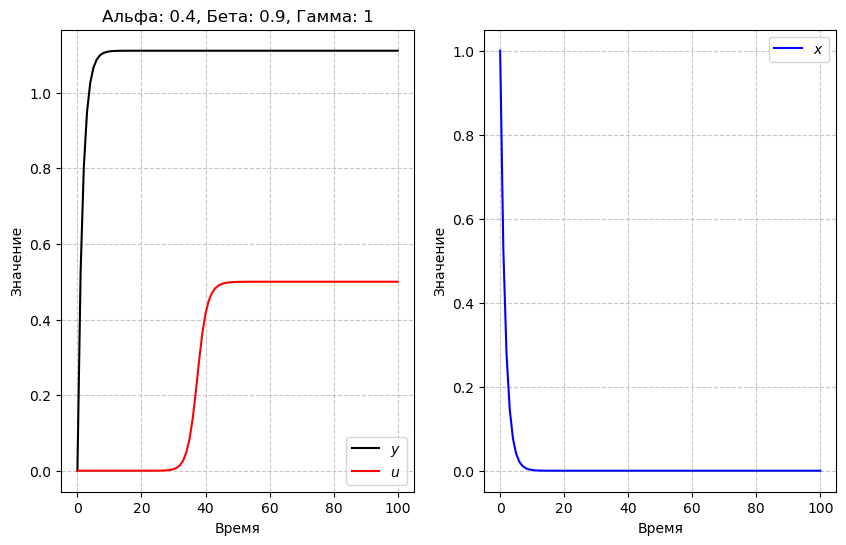

Гамма: 1, Альфа: 0.6, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 1, Альфа: 0.6, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 1, Альфа: 0.6, Бета: 0.7


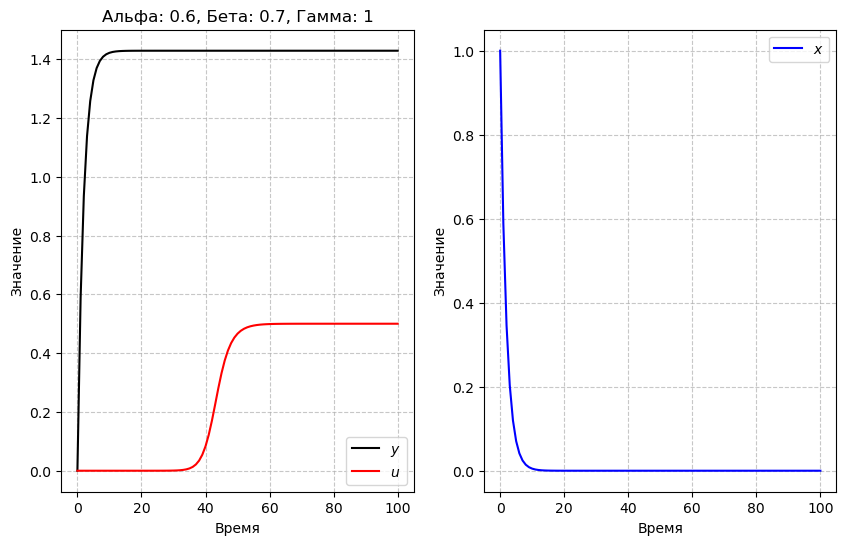

Гамма: 1, Альфа: 0.6, Бета: 0.9


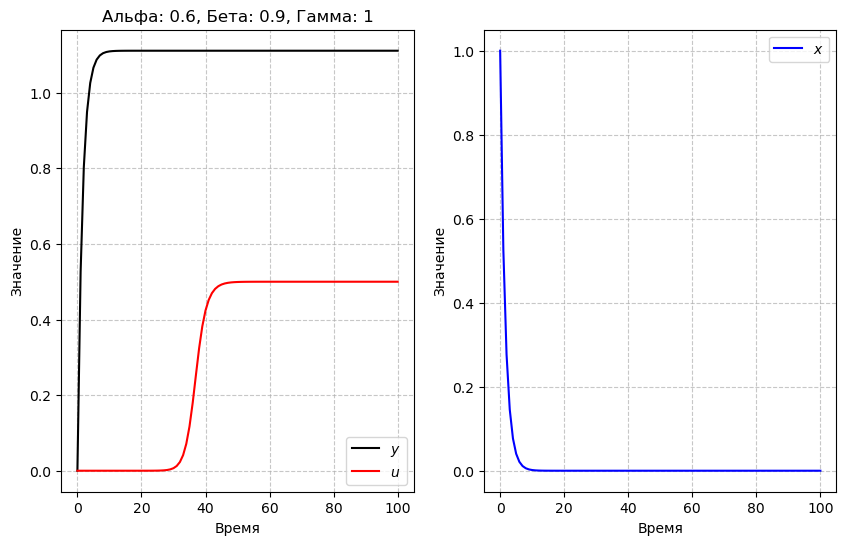

Гамма: 1, Альфа: 0.8, Бета: 0.1
Произошла ошибка типа: Exception
Гамма: 1, Альфа: 0.8, Бета: 0.4
Произошла ошибка типа: Exception
Гамма: 1, Альфа: 0.8, Бета: 0.7


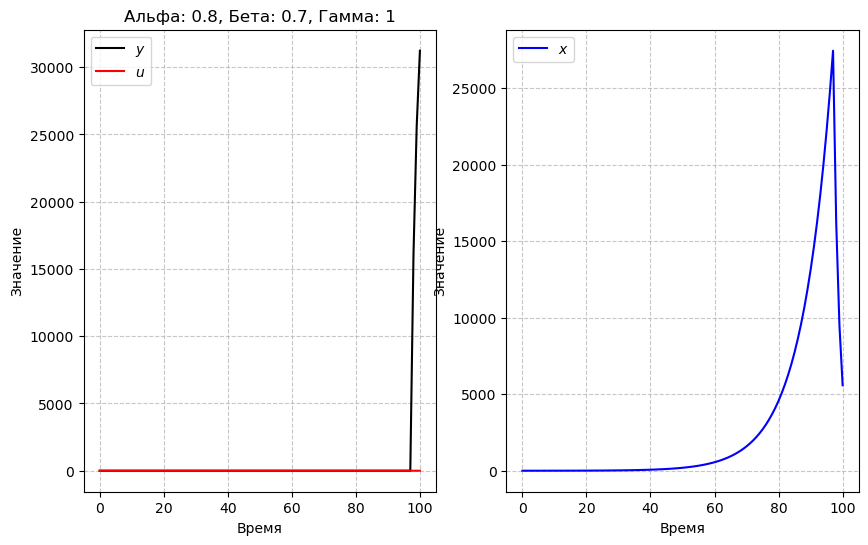

Гамма: 1, Альфа: 0.8, Бета: 0.9


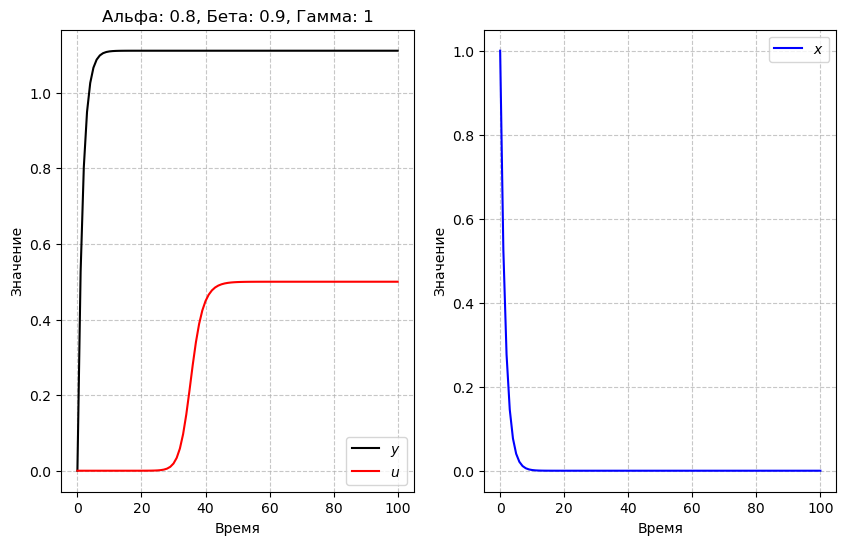

In [20]:
gammas = [0.1, 0.3, 0.7, 0.9, 1]
alphas = [0.2, 0.4, 0.6, 0.8]
betas = [0.1, 0.4, 0.7, 0.9]

for gamma in gammas:
    for alpha in alphas:
        for beta in betas:
            try:
                print(f'Гамма: {gamma}, Альфа: {alpha}, Бета: {beta}')
                model = GEKKO(remote=False)
                time_steps = 101  # Количество временных шагов
                model.time = np.linspace(0, 100, time_steps)  # Временной интервал
                variable_x = model.Var(value=1)  # Начальное значение x
                variable_y = model.Var(value=0)  # Начальное значение y
                time_var = model.Var(value=0) 
                control_var = model.Var(value=0, lb=0, ub=1)
            
                p_vector = np.zeros(time_steps)  # Временной массив
                p_vector[-1] = 1.0 
                final_param = model.Param(value=p_vector)  # Параметр модели
                
                # Уравнения модели
                model.Equation(variable_y.dt() == gamma * (1 - control_var) * variable_x)  # Изменение числа королев
                model.Equation(variable_x.dt() == (alpha * control_var - beta) * variable_x)  # Изменение числа ос
                model.Equation(time_var.dt() == 1)  # Производная времени
                
                model.Obj(-variable_y * final_param) 
                model.options.IMODE = 6  # Задача оптимального управления
                model.solve(disp=False)
                
                # Сравнительный график для y и u
                plt.figure(figsize=(10, 6))
                plt.subplot(1, 2, 1)
                plt.plot(model.time, variable_y.value, 'k-', label=r'$y$')
                plt.plot(model.time, control_var.value, 'r-', label=r'$u$')
                plt.title(f'Альфа: {alpha}, Бета: {beta}, Гамма: {gamma}')
                plt.legend(loc='best')
                plt.ylabel('Значение')
                plt.xlabel('Время')
                plt.grid(True, linestyle='--', alpha=0.7)
            
                # График для x
                plt.subplot(1, 2, 2)
                plt.plot(model.time, variable_x.value, 'b-', label=r'$x$')
                plt.legend(loc='best')
                plt.ylabel('Значение')
                plt.xlabel('Время')
                plt.grid(True, linestyle='--', alpha=0.7)
                plt.show()
            except:
                exc_type, exc_value, exc_traceback = sys.exc_info()
                print(f"Произошла ошибка типа: {exc_type.__name__}")